# Bacteria movement: run and tumble (part I)
## by Abdul Ibrahim

In [1]:
# --------------------------
# Python libraries
# --------------------------
import sys
import numpy as np # numerical computing
import matplotlib.pyplot as plt # plotting
import pandas as pd # data handling
from pathlib import Path # file handling

import scipy.io as sio
import os


sys.path.append(os.path.abspath('../sandbox'))
import metrics # custom metrics for run and tumble analysis

import warnings
warnings.filterwarnings("ignore")

# the code below autoloads new changes (no restart of the kernel needed)
%reload_ext autoreload
%autoreload 2

metrics.py loaded successfully.


In [2]:
# --------------------------
# Notebook path
# --------------------------
os.getcwd() 

'/Users/abdulibrahim/Documents/gitHub/teaching_SoSe26_mobHumAni_exercises/notebooks'

#### observation:
- In previous session, you learned how to load `.csv` data. here we have a `.mat` format which is MATLAB format
- instead we will use scipy.io to handle this MATLAB files (.mat). its best suitable for this

In [3]:
# --------------------------
# loading the data
# --------------------------

base_path = os.path.join("./")
ecoli_path = os.path.join(base_path, "../data", "EcoliTrajectories.mat")

print("Base path:", base_path)
print("E. coli path:", ecoli_path)

ecoli_mat = sio.loadmat(ecoli_path)

print("Keys in E. coli file:", list(ecoli_mat.keys()))

Base path: ./
E. coli path: ./../data/EcoliTrajectories.mat
Keys in E. coli file: ['__header__', '__version__', '__globals__', 'V_10min', 'V_3min', 'V_50min', 'V_7min', 'V_MeAsp1_0511', 'V_MeAsp1_0511_bulk', 'V_MeAsp2_0511', 'V_MeAsp2_0511_bulk', 'V_MeAsp3_0511', 'V_MeAsp3_0511_bulk', 'V_MeAspInverted_1mM_0512_bulk', 'V_MeAsp_0511', 'V_MeAsp_0511_bulk', 'V_MeAsp_0722', 'V_MeAsp_0722_bulk', 'V_MeAsp_0821', 'V_MeAsp_0821_bulk', 'V_MeAsp_1mM_0512_bulk', 'V_Reference_0503_bulk']


# Looking into the data

In [4]:
# --------------------------
# exploring the data structure
# --------------------------


all_keys = list(ecoli_mat.keys())
dataset_keys = [k for k in all_keys if k.startswith('V_')]

dataset_keys

['V_10min',
 'V_3min',
 'V_50min',
 'V_7min',
 'V_MeAsp1_0511',
 'V_MeAsp1_0511_bulk',
 'V_MeAsp2_0511',
 'V_MeAsp2_0511_bulk',
 'V_MeAsp3_0511',
 'V_MeAsp3_0511_bulk',
 'V_MeAspInverted_1mM_0512_bulk',
 'V_MeAsp_0511',
 'V_MeAsp_0511_bulk',
 'V_MeAsp_0722',
 'V_MeAsp_0722_bulk',
 'V_MeAsp_0821',
 'V_MeAsp_0821_bulk',
 'V_MeAsp_1mM_0512_bulk',
 'V_Reference_0503_bulk']

In [5]:
# --------------
# parameters to be used here
# -------------

angle_threshold = 45 # angle change threshold for run/tumble classification (degrees)
V_10min = ecoli_mat['V_10min'] # our dataset for now
ref_t = np.logspace(-1.5, 1.5, 100)
# The crossover between the two happens at τ_c (correlation time).
tau_c = 1.6  # τ_c ≈ 1.6 s for wild-type E. coli (from lecture).
Kd, H = 3.1, 10.3   # Hill parameters (Cluzel et al. 2000)

In [6]:
# --------------
# how many trajectories do we have in V_10min?
# -------------

fps = float(V_10min['Parameters'][0, 0]['fps'][0, 0][0, 0])
dt  = 1.0 / fps
n_traj = len(V_10min['Speeds'][0, 0])
print(f"Number of trajectories in V_10min: {n_traj}")

Number of trajectories in V_10min: 150


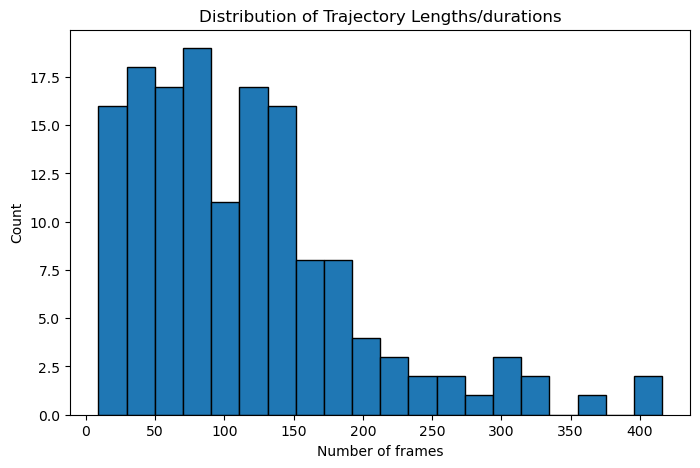

In [7]:
# --------------
# distribution of trajectory lengths/durations
# -------------

lengths = [len(V_10min['Speeds'][0,0][i][0]) for i in range(n_traj)]
plt.figure(figsize=(8, 5)) # adjust figure size here
plt.hist(lengths, bins=20, edgecolor='black')
plt.title("Distribution of Trajectory Lengths/durations")
plt.xlabel("Number of frames")
plt.ylabel("Count")
plt.show()

In [8]:
# --------------
# checking for NaN values in the speed data
# -------------

raw = V_10min['Speeds'][0, 0][0][0]

for col in range(raw.shape[1]):
    n_nan = np.sum(np.isnan(raw[:, col]))
    print(f"col {col} has {n_nan} NaN frames")

col 0 has 0 NaN frames
col 1 has 0 NaN frames
col 2 has 0 NaN frames
col 3 has 0 NaN frames
col 4 has 0 NaN frames
col 5 has 2 NaN frames
col 6 has 2 NaN frames
col 7 has 2 NaN frames
col 8 has 2 NaN frames
col 9 has 6 NaN frames


In [9]:
# --------------
# cleaning the data by removing rows with NaN values in key columns
# -------------

key_cols  = [1, 2, 3, 5, 6, 7, 8, 9]   # x, y, z, speed, angle
valid     = np.all(np.isfinite(raw[:, key_cols]), axis=1)
n_dropped = (~valid).sum()
raw_clean = raw[valid]

In [10]:
raw.shape[0], raw_clean.shape[0]

(146, 140)

In [11]:
# --------------
# creating a clean DataFrame for our analysis
# -------------

df = pd.DataFrame({
    'frame'           : raw_clean[:, 0].astype(int),
    'time_s'          : raw_clean[:, 0] / fps,
    'x_um'            : raw_clean[:, 1],
    'y_um'            : raw_clean[:, 2],
    'z_um'            : raw_clean[:, 3],
    'vx_um_s'         : raw_clean[:, 5],  
    'vy_um_s'         : raw_clean[:, 6],  
    'vz_um_s'         : raw_clean[:, 7],  
    'speed_um_s'      : raw_clean[:, 8],  
    'angle_change_deg': raw_clean[:, 9],  
}).reset_index(drop=True)

In [12]:
# --------------
# preview the cleaned DataFrame
# -------------

df.head(10) # show first 10 rows only

,frame,time_s,x_um,y_um,z_um,vx_um_s,vy_um_s,vz_um_s,speed_um_s,angle_change_deg
0,4,0.266667,89.100077,258.592708,-41.413207,9.206089,0.019106,-2.158903,9.455861,6.117073
1,5,0.333333,89.839966,258.593537,-41.558005,11.099129,0.005957,-2.158359,11.307043,12.674389
2,6,0.400000,90.579960,258.593502,-41.700988,11.100586,1.163334,-2.156907,11.367876,22.743116
3,7,0.466667,91.320044,258.748648,-41.845593,11.102052,3.763083,-2.159476,11.919719,27.963840
4,8,0.533333,92.060234,259.095246,-41.988918,9.782858,5.205981,-2.155944,11.289582,15.602570
5,9,0.600000,92.624425,259.442779,-42.133052,7.209506,5.226207,-2.159274,9.162569,30.488367
6,10,0.666667,93.021501,259.792074,-42.276821,5.831614,1.703700,-1.719510,6.314034,74.353289
7,11,0.733333,93.401974,259.669939,-42.362320,5.708669,-3.283126,-1.283128,6.709265,97.234843
8,12,0.800000,93.782657,259.354324,-42.447905,5.711121,-7.856999,-1.283217,9.797754,77.145673
9,13,0.866667,94.163456,258.622339,-42.533416,2.813122,-17.380517,-1.849707,17.703599,45.391308


In [13]:
'''
cell_size = 1.5
pers_length = [1,1.3, 1.5, 2, 2.5, 3]
for i in pers_length:
    ratio_ = i / cell_size
    print(f"Persistence length: {i} μm, Ratio to cell size: {ratio_:.2f}")
'''

'\ncell_size = 1.5\npers_length = [1,1.3, 1.5, 2, 2.5, 3]\nfor i in pers_length:\n    ratio_ = i / cell_size\n    print(f"Persistence length: {i} μm, Ratio to cell size: {ratio_:.2f}")\n'

# Task 1

In [14]:
df.columns

Index(['frame', 'time_s', 'x_um', 'y_um', 'z_um', 'vx_um_s', 'vy_um_s',
       'vz_um_s', 'speed_um_s', 'angle_change_deg'],
      dtype='str')

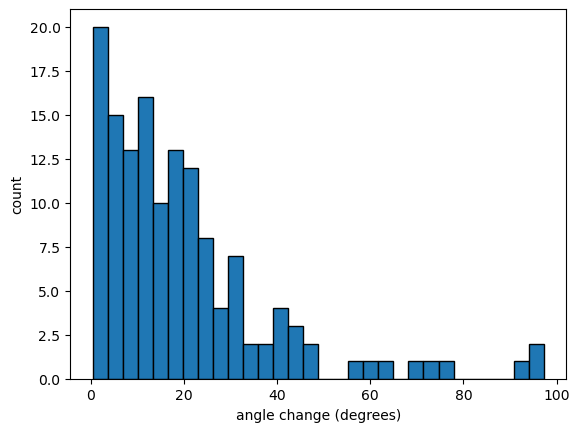

In [15]:
'''
plot a histogram of column 10 (angular change in direction between frames)
'''

plt.hist(df['angle_change_deg'], bins=30, edgecolor='black')
plt.xlabel("angle change (degrees)")
plt.ylabel("count")
plt.show()

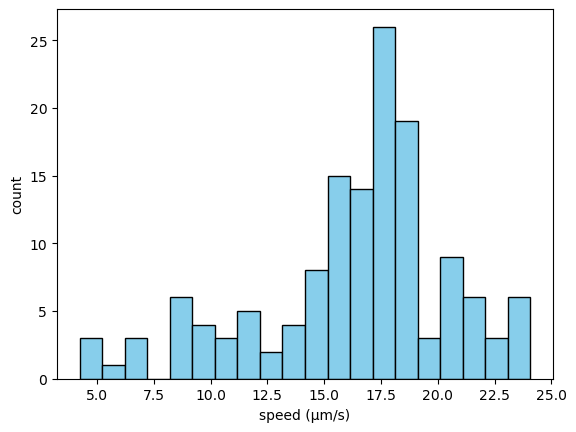

In [16]:
'''
plot a histogram of speed
'''

plt.hist(df.speed_um_s, bins=20, edgecolor='black', color='skyblue')  
plt.xlabel("speed (μm/s)")
plt.ylabel("count")
plt.show()

In [17]:
df.angle_change_deg.describe()

count    140.000000
mean      20.035212
std       19.058160
min        0.429627
25%        6.832263
50%       15.717110
75%       25.902145
max       97.234843
Name: angle_change_deg, dtype: float64

In [18]:
'''
find out the average speed, angle, and durations from the dataframe (i.e., statistics)
'''
mean_val = np.mean(df.angle_change_deg)
mean_speed = np.mean(df.speed_um_s)
print(f'my mean angle change: {mean_val:.2f} degrees')
print(f'my mean speed: {mean_speed:.2f} μm/s')

my mean angle change: 20.04 degrees
my mean speed: 16.28 μm/s


# task 2

In [19]:
'''
N_CELLS = 1
COLORS  = ['#1D9E75', '#4A90D9', '#E8825A', '#9B8FD4', '#F0C060'] 
trajs = [metrics.extract_clean(V_10min, i)[0] for i in range(N_CELLS)]
# trajs = [metrics.extract_clean(V_10min, 1)[0]]
'''

"\nN_CELLS = 1\nCOLORS  = ['#1D9E75', '#4A90D9', '#E8825A', '#9B8FD4', '#F0C060'] \ntrajs = [metrics.extract_clean(V_10min, i)[0] for i in range(N_CELLS)]\n# trajs = [metrics.extract_clean(V_10min, 1)[0]]\n"

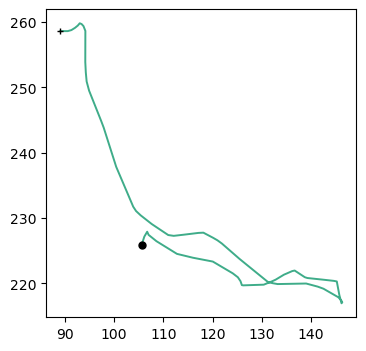

In [20]:
'''
2.1. plot one trajectory using the x and y coordinates. also plot the speed.
'''

plt.figure(figsize=(4, 4))
plt.plot(df['x_um'], df['y_um'], color='#1D9E75', lw=1.4, alpha=0.85, label=f'cell 1')
plt.plot(df['x_um'].values[0], df['y_um'].values[0], '+', color='black', ms=5, zorder=5)
plt.plot(df['x_um'].values[-1], df['y_um'].values[-1], 'o', color='black', ms=5, zorder=5)
plt.show()

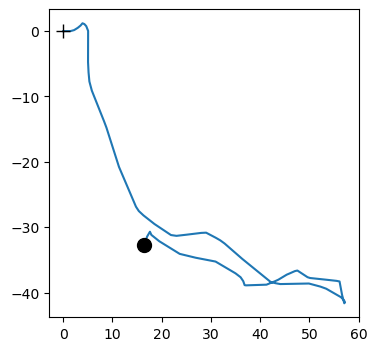

In [21]:
'''
replotting the trajectory starting from the origin (0, 0)
'''

plt.figure(figsize=(4, 4))
x_position = df['x_um'] - df['x_um'].values[0] # actual x_positon - first x_position to start at 0
y_position = df['y_um'] - df['y_um'].values[0] # actual y_position - first y_position to start at 0
plt.plot(x_position, y_position) #plot trajectory only
plt.plot(x_position.values[0], y_position.values[0], '+', color='black', ms=10, zorder=5) # plot starting point +
plt.plot(x_position.values[-1], y_position.values[-1], 'o', color='black', ms=10, zorder=5) # ending point o
plt.show()

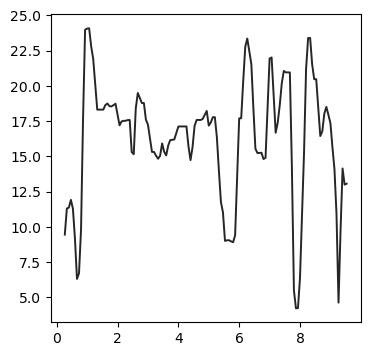

In [22]:
'''
2.1. also plot the speed.
'''

plt.figure(figsize=(4, 4))
plt.plot(df['time_s'], df['speed_um_s'], color='black', lw=1.4, alpha=0.85, label=f'cell 1')
plt.show()

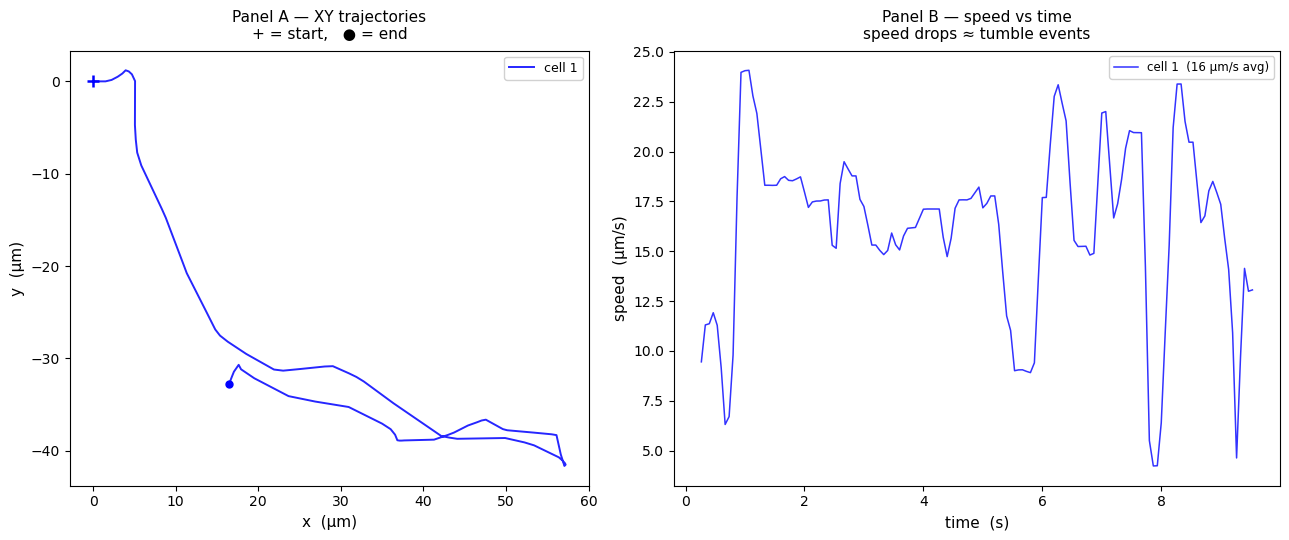

In [23]:
'''
plotting both the trajectory and speed in one figure
'''

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), facecolor='white',gridspec_kw={'width_ratios': [1.2, 1.4]})
# fig.subplots_adjust(wspace=0.5)

color_b = 'b' # blue color
trajs = [metrics.extract_clean(V_10min, 0)[0]]
# ------ Panel A: x-y trajectories ------
for i, df in enumerate(trajs):
    x = df['x_um'].values - df['x_um'].iloc[0]
    y = df['y_um'].values - df['y_um'].iloc[0]
    ax1.plot(x, y, color=color_b, lw=1.4, alpha=0.85, label=f'cell {i+1}')
    ax1.plot(0, 0, '+', color=color_b, ms=9, mew=1.8, zorder=5)
    ax1.plot(x[-1], y[-1], 'o', color=color_b, ms=5, zorder=5)
 
ax1.set_xlabel('x  (µm)', fontsize=11)
ax1.set_ylabel('y  (µm)', fontsize=11)
ax1.set_title('Panel A — XY trajectories\n' '+ = start,   ● = end', fontsize=11, pad=8)
ax1.legend(fontsize=9, framealpha=0.9, edgecolor='#ccc')
 
# ------ Panel B: speed vs time ------
for i, df in enumerate(trajs):
    ax2.plot(df['time_s'], df['speed_um_s'], color=color_b, lw=1.1, alpha=0.8,
             label=f'cell {i+1}  ' f'({df["speed_um_s"].mean():.0f} µm/s avg)')

ax2.set_xlabel('time  (s)', fontsize=11)
ax2.set_ylabel('speed  (µm/s)', fontsize=11)
ax2.set_title('Panel B — speed vs time\n' 'speed drops ≈ tumble events', fontsize=11, pad=8)
ax2.legend(fontsize=8.5, framealpha=0.9, edgecolor='#ccc',loc='upper right')

plt.tight_layout()
plt.show()

In [24]:
np.mean(df['speed_um_s'])

np.float64(16.28283204200667)

In [25]:
'''
approach 1: count the number of tumbles (angle change > 45°)
'''

(df.angle_change_deg > angle_threshold).value_counts()

angle_change_deg
False    127
True      13
Name: count, dtype: int64

In [26]:
'''
approach 2: count the number of tumbles (angle change > 45°)
'''

n_tumble =(df.angle_change_deg > angle_threshold).sum()
print(f"Number of tumbles (angle change > {angle_threshold}°): {n_tumble}")

Number of tumbles (angle change > 45°): 13


* both cells above do the same. there are 13 tumbles > angle_threshold (i.e., 45)

In [27]:
'''
2.2. For trajectory in 2.1. count the number of tumble frames.
we are doing this for the 150 trajectories in V_10min
'''

n_avail = len(V_10min['Speeds'][0, 0])

tumble_freqs = []
durations    = []

for i in range(n_avail):
    df, fps = metrics.extract_clean(V_10min, i)

    n_frames = len(df)
    duration_s = df['time_s'].max()

    is_tumble = df['angle_change_deg'] > angle_threshold
    n_tumble = is_tumble.sum()
    f_tumble = n_tumble / duration_s # if duration_s > 0 else np.nan

    tumble_freqs.append(f_tumble)
print(f"Calculated tumble frequencies for {len(tumble_freqs)} trajectories.")

Calculated tumble frequencies for 150 trajectories.


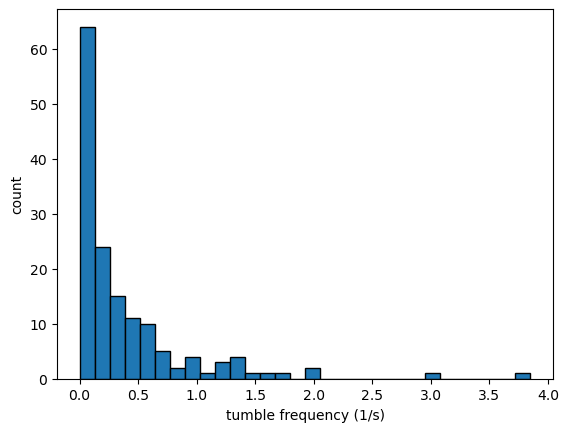

In [28]:
# plot the distribution of tumble frequencies across all trajectories

plt.hist(tumble_freqs, bins=30, edgecolor='black')
plt.xlabel("tumble frequency (1/s)")
plt.ylabel("count")
plt.show()

* interpretation: most trajectories have tumble frequencies between 0 and 0.5 tumbles/s, with a peak around 0.1 tumbles/s. This suggests that most cells tumble infrequently, but there is variability in tumble frequency across the population.

In [29]:
'''
we will use get_cw_bias abd get_cheyp from metrics.py
you can take a look at the code in metrics.py to understand how these functions work.
or as follows:
'''
help(metrics.get_cw_bias)
# help(metrics.get_cheyp)

Help on function get_cw_bias in module metrics:

get_cw_bias(V, angle_threshold)
    Compute the CW bias (tumble bias) for each trajectory in V based on the fraction of frames where the angle change exceeds a specified threshold.
    Args:
        V: Structured container holding speed and parameter arrays, including 'Speeds' and 'Parameters' with an 'fps' field.
        angle_threshold: value representing the minimum angle change (in degrees) required for a frame

    return: CW bias values for each trajectory



V_10min — mean CW bias: 0.099  → [CheY-P] ≈ 2.00 µM
V_50min — mean CW bias: 0.121  → [CheY-P] ≈ 2.18 µM


Text(0, 0.5, 'CW bias')

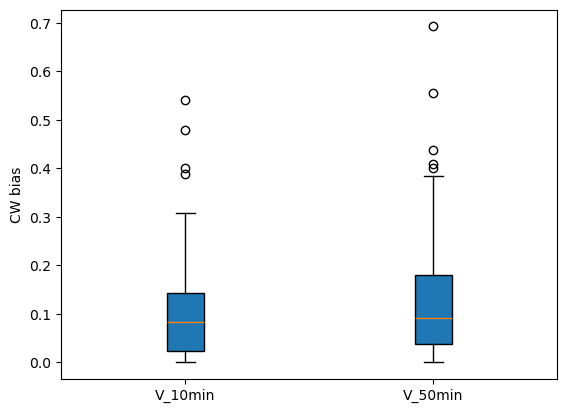

In [30]:
'''
2.4. Using the Hill equation
here we wll use get_cw_bias abd get_cheyp from metrics.py
'''

bias_10 = metrics.get_cw_bias(V_10min, angle_threshold) # V_10min = ecoli_mat['V_10min']
bias_50 = metrics.get_cw_bias(ecoli_mat['V_50min'], angle_threshold)

cheyp_10 =  metrics.get_cheyp(Kd, H, bias_10)
cheyp_50 = metrics.get_cheyp(Kd, H, bias_50)

print(f"V_10min — mean CW bias: {bias_10.mean():.3f}  " f"→ [CheY-P] ≈ {cheyp_10.mean():.2f} µM")
print(f"V_50min — mean CW bias: {bias_50.mean():.3f}  " f"→ [CheY-P] ≈ {cheyp_50.mean():.2f} µM")

# boxplot of CW bias for V_10min and V_50min
data = [bias_10, bias_50]
plt.boxplot(data, labels=['V_10min', 'V_50min'], patch_artist=True)
plt.ylabel("CW bias")

Text(0, 0.5, 'CheY-P (µM)')

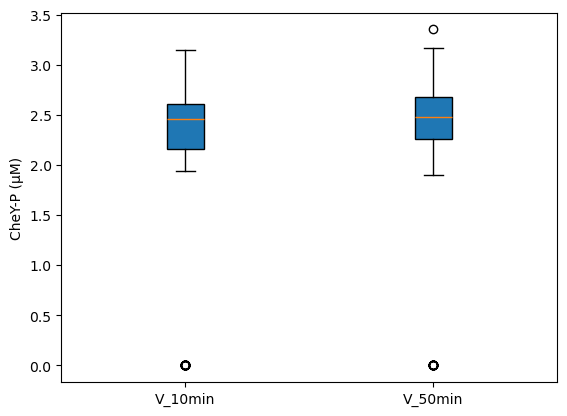

In [31]:
data = [cheyp_10, cheyp_50]
plt.boxplot(data, labels=['V_10min', 'V_50min'], patch_artist=True)
plt.ylabel("CheY-P (µM)")

 - CW bias is a dimensionless fraction between 0 and 1. It is simply the proportion of frames where the cell was tumbling. A value of 0.10 means the cell spent 10% of its time tumbling.
 -  [CheY-P] is a concentration in µM, so the y-axis goes from 0 to ~3.5 µM. It is not measured directly — it is inferred by plugging the CW bias into the inverted Hill equation
 - So a CW bias of 0.10 on the left corresponds to roughly 2.4 µM on the right. 

# task 3

In [32]:
'''
3.1. computes the time-averaged MSD for each 
trajectory using the function given in lecture (see metrics.compute_msd(...) for this)

the function to be used is as follows:
'''

help(metrics.compute_msd)

Help on function compute_msd in module metrics:

compute_msd(df)
    Time-averaged MSD.

    MSD(τ) = (1/N) Σ |r(t+τ) - r(t)|²

    Parameters
    ----------
    df : DataFrame with columns x_um, y_um, z_um, time_s
        (already NaN-cleaned)

    Returns
    -------
    lags : array of time lags τ (seconds)
    msd  : array of MSD values (µm²)



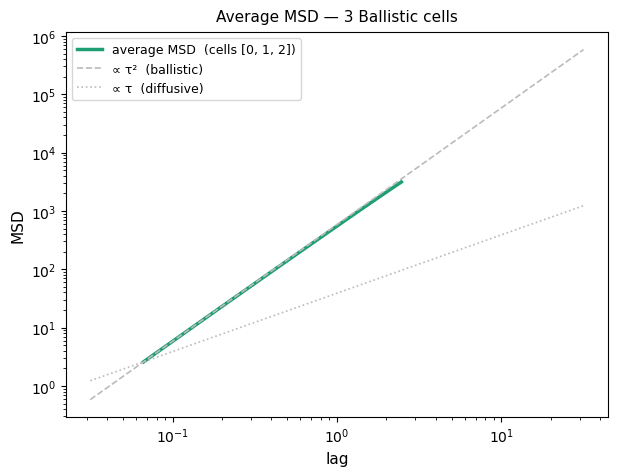

In [33]:
'''
3.2. plot MSD for three trajectories in V_10min using 
idx [0,1,2]
'''

CELLS = [0,1,2]

all_lags, all_msd = [], []
for idx in CELLS:
    df, fps = metrics.extract_clean(V_10min, idx) # extract clean df
    lags, msd = metrics.compute_msd(df) # compute MSD for the trajectory
    all_lags.append(lags) # store lags for each trajectory  
    all_msd.append(msd) # store MSD for each trajectory

min_len  = min(len(m) for m in all_msd)
avg_lags = all_lags[0][:min_len]
avg_msd  = np.mean([m[:min_len] for m in all_msd], axis=0)
# ------------- plot -------------
fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
anchor, t0 = avg_msd[0], avg_lags[0]
plt.loglog(avg_lags, avg_msd, color='#1D9E75', lw=2.5, label=f'average MSD  (cells {CELLS})') # plotting the average MSD
plt.loglog(ref_t, anchor*(ref_t/t0)**2, '--', color='#bbb', lw=1.2, label='∝ τ²  (ballistic)') # plotting the reference line for ballistic motion (MSD ∝ τ²)
plt.loglog(ref_t, anchor*(ref_t/t0)**1, ':',  color='#bbb',lw=1.2, label='∝ τ  (diffusive)')

plt.xlabel(r'lag', fontsize=11) 
plt.ylabel(r'MSD', fontsize=11) 
plt.title(f'Average MSD — {len(CELLS)} Ballistic cells', fontsize=11, pad=8)
plt.legend(fontsize=9, edgecolor='#ccc')
plt.show()


interpretation of the MSD plot:
- The average MSD curve (green) shows how the mean squared displacement of the cells changes with time lag (τ).
- The dashed line (gray) represents the expected MSD for ballistic motion, where MSD ∝ τ². If the average MSD follows this line, it suggests that the cells are moving in a straight line with constant speed (ballistic behavior).
- The dotted line (gray) represents the expected MSD for diffusive motion, where MSD ∝ τ. If the average MSD follows this line, it suggests that the cells are undergoing random walk-like behavior (diffusive motion).

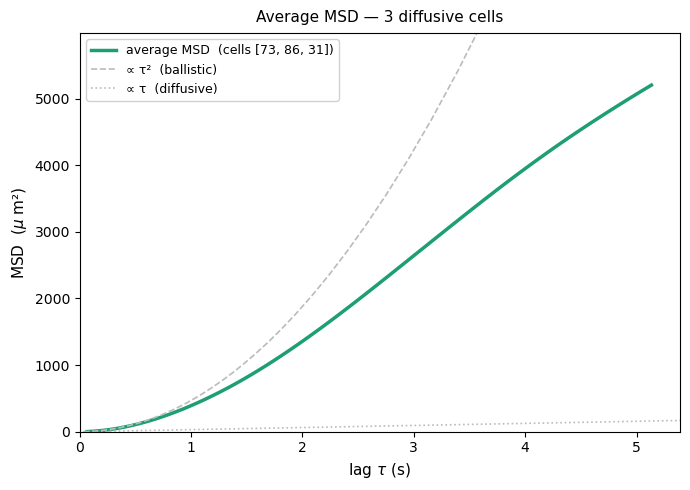

In [34]:
'''
3.2. plot MSD for three trajectories in V_10min using idx [73, 86, 31]
'''

CELLS = [73, 86, 31]

# ----- compute average MSD -----
all_lags, all_msd = [], []
for idx in CELLS:
    df, fps   = metrics.extract_clean(V_10min, idx) # clean the trajectory data for the given index
    lags, msd = metrics.compute_msd(df) # compute MSD for the trajectory
    all_lags.append(lags)
    all_msd.append(msd)

min_len  = min(len(m) for m in all_msd)
avg_lags = all_lags[0][:min_len]
avg_msd  = np.mean([m[:min_len] for m in all_msd], axis=0)
# ------------- plot -------------
plt.figure(figsize=(7, 5), facecolor='white')
anchor, t0 = avg_msd[0], avg_lags[0]

plt.plot(avg_lags, avg_msd, color='#1D9E75', lw=2.5, label=f'average MSD  (cells {CELLS})') # plotting the average MSD
plt.plot(ref_t, anchor*(ref_t/t0)**2, '--', color='#bbb', lw=1.2, label='∝ τ²  (ballistic)') # plotting the reference line for ballistic motion (MSD ∝ τ²)
plt.plot(ref_t, anchor*(ref_t/t0)**1, ':',  color='#bbb',lw=1.2, label='∝ τ  (diffusive)')

plt.xlim(0, avg_lags[-1] * 1.05)
plt.ylim(0, avg_msd.max() * 1.15)
plt.xlabel(r'lag $\tau$ (s)', fontsize=11)
plt.ylabel(r'MSD  ($\mu$ m²)', fontsize=11)
plt.title('Average MSD — 3 diffusive cells', fontsize=11, pad=8)
plt.legend(fontsize=9, framealpha=0.9, edgecolor='#ccc')

plt.tight_layout()
plt.show()


interpretation of the MSD plot:
- The average MSD curve (green) shows how the mean squared displacement of the cells changes with time lag (τ).
- The dashed line (gray) represents the expected MSD for ballistic motion, where MSD ∝ τ². If the average MSD follows this line, it suggests that the cells are moving in a straight line with constant speed (ballistic behavior).
- The dotted line (gray) represents the expected MSD for diffusive motion, where MSD ∝ τ. If the average MSD follows this line, it suggests that the cells are undergoing random walk-like behavior (diffusive motion).

# task 4

In [35]:
'''
compute the net displacement in the x, y, and z 
directions. what’s the mean displacement in any direction?
'''
datasets = {
    'no gradient' : ecoli_mat['V_Reference_0503_bulk'],
    'gradient'    : ecoli_mat['V_MeAsp_0511_bulk'],
}

for row, (name, V_cond) in enumerate(datasets.items()):
    dx, dy, dz = [], [], []
    # note: V_cond['Speeds'][0, 0] is collection of all tracked cell trajectory tables
    for i in range(len(V_cond['Speeds'][0, 0])):
        df, fps = metrics.extract_clean(V_cond, i)
        if len(df) < 10: continue # skip very short trajectories
        dx.append(df['x_um'].iloc[-1] - df['x_um'].iloc[0])
        dy.append(df['y_um'].iloc[-1] - df['y_um'].iloc[0])
        dz.append(df['z_um'].iloc[-1] - df['z_um'].iloc[0])

    dx, dy, dz = np.array(dx), np.array(dy), np.array(dz)
    print(f"\n{name}:")
    print(f"  Δx mean = {dx.mean():.2f} µm")
    print(f"  Δy mean = {dy.mean():.2f} µm")
    print(f"  Δz mean = {dz.mean():.2f} µm")
    



no gradient:
  Δx mean = -0.98 µm
  Δy mean = -0.32 µm
  Δz mean = 0.24 µm

gradient:
  Δx mean = -7.87 µm
  Δy mean = -0.07 µm
  Δz mean = -0.21 µm


* interpretation of no gradient vs gradient:

in the no gradient condition, the mean displacements in x, y, and z directions are close to zero, indicating that the cells are moving randomly without a preferred direction. in contrast, in the gradient condition, we see a significant mean displacement in the x direction (towards the attractant), while the mean displacements in y and z directions remain close to zero. this suggests that the cells are exhibiting chemotaxis by moving preferentially towards higher concentrations of the attractant along the x-axis.  


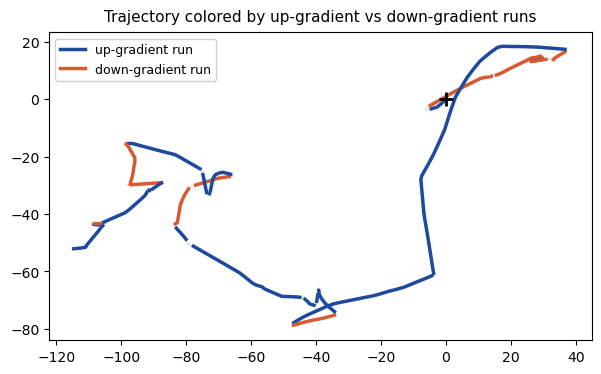

In [36]:
"""
plotting the trajectory of one cell in the gradient condition, colored by up-gradient vs down-gradient segments.
"""

V_grad = ecoli_mat['V_MeAsp_0511_bulk']
idx_ = 7696

df_ex, fps_ex = metrics.extract_clean(V_grad, idx_)
plt.figure(figsize=(7, 4), facecolor='white')

df_ex['is_run'] = df_ex['angle_change_deg'] < angle_threshold # run
df_ex['seg'] = (df_ex['is_run'] != df_ex['is_run'].shift(1)).cumsum() #     did the state change?

x = df_ex['x_um'].values - df_ex['x_um'].iloc[0]
y = df_ex['y_um'].values - df_ex['y_um'].iloc[0]
plt.plot(x, y, color='#ddd', lw=1.0, zorder=1) #plot trajectory

for _, grp in df_ex[df_ex['is_run']].groupby('seg'):
    idx_g = grp.index
    gx = x[idx_g]
    gy = y[idx_g]
    c  = '#1D4A9E' if grp['vx_um_s'].mean() < 0 else '#D85A30'  
    plt.plot(gx, gy, color=c, lw=2.5, zorder=2) # plot run segments colored by up-gradient (blue) vs down-gradient (red)

plt.plot(0, 0, '+k', ms=10, mew=2, zorder=5) # plot starting point +
plt.title('Trajectory colored by up-gradient vs down-gradient runs', fontsize=11, pad=8)

from matplotlib.lines import Line2D
plt.legend(handles=[
    Line2D([0],[0], color='#1D4A9E', lw=2.5, label='up-gradient run'),
    Line2D([0],[0], color='#D85A30', lw=2.5, label='down-gradient run'),
], fontsize=9, framealpha=0.9, edgecolor='#ccc')

plt.show()

-------- end of exercise ------